<a href="https://colab.research.google.com/github/khansa-020/Deep-Fake-Detection/blob/main/DeepFake_SimpleCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()


!pip install -q kaggle

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d manjilkarki/deepfake-and-real-images
!unzip deepfake-and-real-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: Dataset/Validation/Real/real_5499.jpg  
  inflating: Dataset/Validation/Real/real_55.jpg  
  inflating: Dataset/Validation/Real/real_550.jpg  
  inflating: Dataset/Validation/Real/real_5500.jpg  
  inflating: Dataset/Validation/Real/real_5501.jpg  
  inflating: Dataset/Validation/Real/real_5502.jpg  
  inflating: Dataset/Validation/Real/real_5503.jpg  
  inflating: Dataset/Validation/Real/real_5504.jpg  
  inflating: Dataset/Validation/Real/real_5505.jpg  
  inflating: Dataset/Validation/Real/real_5506.jpg  
  inflating: Dataset/Validation/Real/real_5507.jpg  
  inflating: Dataset/Validation/Real/real_5508.jpg  
  inflating: Dataset/Validation/Real/real_5509.jpg  
  inflating: Dataset/Validation/Real/real_551.jpg  
  inflating: Dataset/Validation/Real/real_5510.jpg  
  inflating: Dataset/Validation/Real/real_5511.jpg  
  inflating: Dataset/Validation/Real/real_5512.jpg  
  inflating: Dataset/Validation/Real/real_5513.jpg  

In [ ]:
import os

print("Train:", os.listdir("Dataset/Train"))
print("Validation:", os.listdir("Dataset/Validation"))
print("Test:", os.listdir("Dataset/Test"))

print("Real:", len(os.listdir("Dataset/Train/Real")))
print("Fake:", len(os.listdir("Dataset/Train/Fake")))

print("Real:", len(os.listdir("Dataset/Test/Real")))
print("Fake:", len(os.listdir("Dataset/Test/Fake")))

print("Real:", len(os.listdir("Dataset/Validation/Real")))
print("Fake:", len(os.listdir("Dataset/Validation/Fake")))

Train: ['Fake', 'Real']
Validation: ['Fake', 'Real']
Test: ['Fake', 'Real']
Real: 70001
Fake: 70001
Real: 5413
Fake: 5492
Real: 19787
Fake: 19641


In [ ]:
import os
import random
import shutil

base_path = "Dataset"

train_real = os.path.join(base_path, "Train/Real")
train_fake = os.path.join(base_path, "Train/Fake")

val_real = os.path.join(base_path, "Validation/Real")
val_fake = os.path.join(base_path, "Validation/Fake")


output_base = "Subset_Dataset"

os.makedirs(output_base, exist_ok=True)

for split in ["train", "test", "val"]:
    for cls in ["Real", "Fake"]:
        os.makedirs(os.path.join(output_base, split, cls), exist_ok=True)

In [ ]:
real_images = os.listdir(train_real)
fake_images = os.listdir(train_fake)

real_sample = random.sample(real_images, 2500)
fake_sample = random.sample(fake_images, 2500)

for img in real_sample:
    shutil.copy(
        os.path.join(train_real, img),
        os.path.join(output_base, "train/Real", img)
    )

for img in fake_sample:
    shutil.copy(
        os.path.join(train_fake, img),
        os.path.join(output_base, "train/Fake", img)
    )

print("Real:", len(os.listdir("Subset_Dataset/train/Real")))
print("Fake:", len(os.listdir("Subset_Dataset/train/Fake")))
print("Train subset created ✔")

Real: 2500
Fake: 2500
Train subset created ✔


In [ ]:
val_real_imgs = os.listdir(val_real)
val_fake_imgs = os.listdir(val_fake)

val_real_sample = random.sample(val_real_imgs, 500)
val_fake_sample = random.sample(val_fake_imgs, 500)

for img in val_real_sample:
    shutil.copy(
        os.path.join(val_real, img),
        os.path.join(output_base, "val/Real", img)
    )

for img in val_fake_sample:
    shutil.copy(
        os.path.join(val_fake, img),
        os.path.join(output_base, "val/Fake", img)
    )

print("Real:", len(os.listdir("Subset_Dataset/val/Real")))
print("Fake:", len(os.listdir("Subset_Dataset/val/Fake")))
print("Validation subset created ✔")


Real: 500
Fake: 500
Validation subset created ✔


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

base = "Subset_Dataset"

# =========================
# PATHS
# =========================

train_real_path = os.path.join(base, "train/Real")
train_fake_path = os.path.join(base, "train/Fake")

# =========================
# CREATE OUTPUT FOLDERS
# =========================

os.makedirs(os.path.join(base, "final_train/Real"), exist_ok=True)
os.makedirs(os.path.join(base, "final_train/Fake"), exist_ok=True)

os.makedirs(os.path.join(base, "test/Real"), exist_ok=True)
os.makedirs(os.path.join(base, "test/Fake"), exist_ok=True)

# =========================
# LOAD IMAGE NAMES
# =========================

real_images = os.listdir(train_real_path)
fake_images = os.listdir(train_fake_path)

# =========================
# SPLIT REAL IMAGES
# =========================

train_real_imgs, test_real_imgs = train_test_split(
    real_images,
    test_size=0.2,
    random_state=42
)

# =========================
# SPLIT FAKE IMAGES
# =========================

train_fake_imgs, test_fake_imgs = train_test_split(
    fake_images,
    test_size=0.2,
    random_state=42
)

# =========================
# COPY TRAIN REAL
# =========================

for img in train_real_imgs:
    shutil.copy(
        os.path.join(train_real_path, img),
        os.path.join(base, "final_train/Real", img)
    )

# =========================
# COPY TRAIN FAKE
# =========================

for img in train_fake_imgs:
    shutil.copy(
        os.path.join(train_fake_path, img),
        os.path.join(base, "final_train/Fake", img)
    )

# =========================
# COPY TEST REAL
# =========================

for img in test_real_imgs:
    shutil.copy(
        os.path.join(train_real_path, img),
        os.path.join(base, "test/Real", img)
    )

# =========================
# COPY TEST FAKE
# =========================

for img in test_fake_imgs:
    shutil.copy(
        os.path.join(train_fake_path, img),
        os.path.join(base, "test/Fake", img)
    )

# =========================
# VERIFY COUNTS
# =========================

for split in ["final_train", "test", "val"]:
    print(f"\n{split.upper()}")

    for cls in ["Real", "Fake"]:
        path = os.path.join(base, split, cls)
        print(cls, ":", len(os.listdir(path)))


FINAL_TRAIN
Real : 2000
Fake : 2000

TEST
Real : 500
Fake : 500

VAL
Real : 500
Fake : 500


Using Device: cpu
Classes: ['Fake', 'Real']

MODEL HYPERPARAMETERS
Total Parameters     : 25,784,578
Trainable Parameters : 25,784,578
Patch Size           : N/A (CNN)
Batch Size           : 16
Hidden Layer         : 256
Classification Layer : Linear
Layers Number        : 3
Learning Rate        : 0.0001
Pooling              : MaxPool2d
Filters              : [32, 64, 128]
Dropout              : 0.3
Warmup Steps         : 2
Total Epochs         : 15

TRAINING STARTED
Epoch [1/15] | TrainLoss: 0.7921 | TrainAcc: 63.95% | ValLoss: 0.6021 | ValAcc: 69.20% | TestLoss: 0.5803 | TestAcc: 72.50% | LR: 0.000099 | Time: 993.06s
Epoch [2/15] | TrainLoss: 0.5815 | TrainAcc: 70.97% | ValLoss: 0.6143 | ValAcc: 70.10% | TestLoss: 0.5826 | TestAcc: 69.90% | LR: 0.000096 | Time: 1031.47s
Epoch [3/15] | TrainLoss: 0.5531 | TrainAcc: 75.10% | ValLoss: 0.5638 | ValAcc: 71.10% | TestLoss: 0.5261 | TestAcc: 75.80% | LR: 0.000090 | Time: 950.54s
Epoch [4/15] | TrainLoss: 0.5310 | TrainAcc: 76.78% | ValLoss:

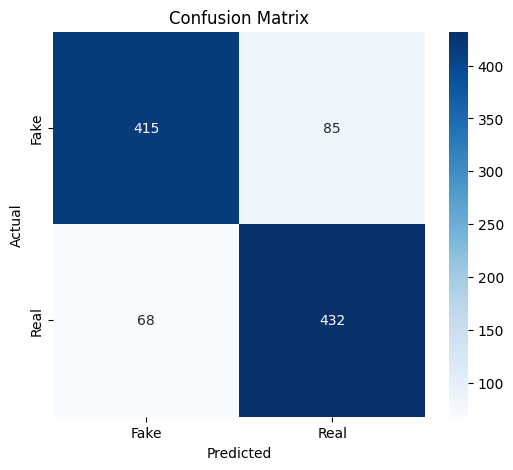

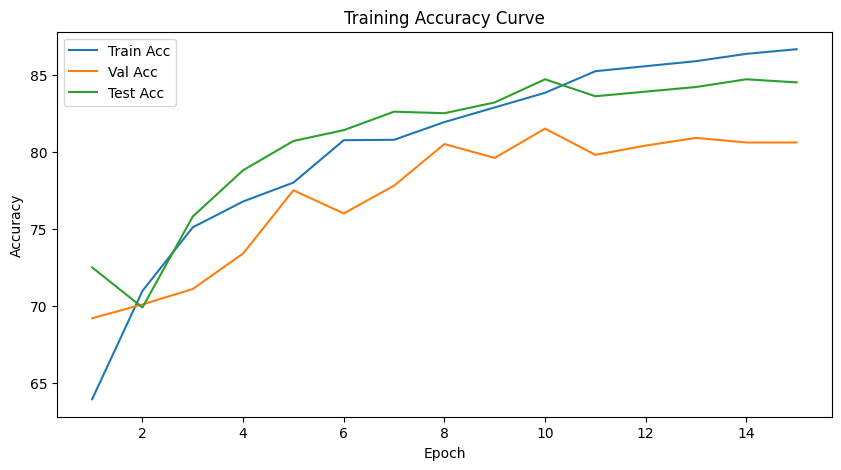

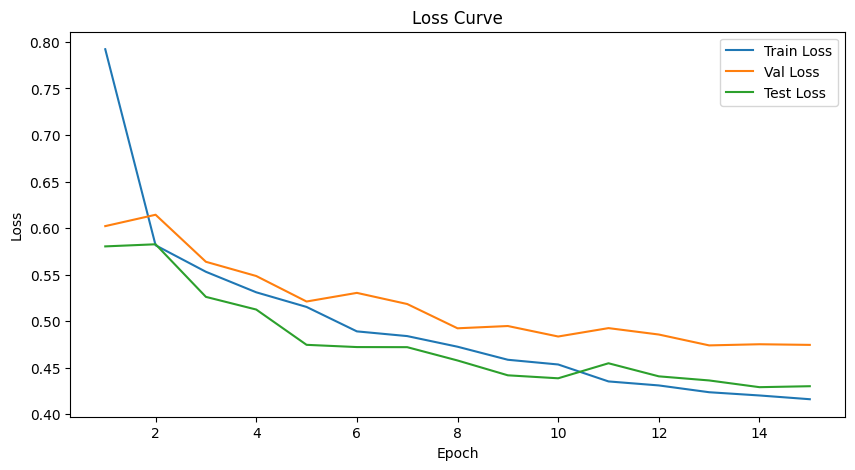


ALL OUTPUTS SAVED SUCCESSFULLY
Models Folder      : /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn/models
Checkpoints Folder : /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn/checkpoints
Logs Folder        : /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn/logs
Plots Folder       : /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn/plots
Inference Folder   : /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn/inference


'\ncheckpoint = torch.load(\n    os.path.join(CHECKPOINT_DIR, "checkpoint_epoch_5.pth")\n)\n\nmodel.load_state_dict(checkpoint["model_state_dict"])\noptimizer.load_state_dict(checkpoint["optimizer_state_dict"])\nscheduler.load_state_dict(checkpoint["scheduler_state_dict"])\n\nstart_epoch = checkpoint["epoch"]\n'

In [ ]:
# ============================================================
# 1. INSTALLS
# ============================================================
!pip install -q timm

# ============================================================
# 2. IMPORTS
# ============================================================
import os
import json
import time
import copy
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler

from torchvision import datasets, transforms
from torchvision.utils import make_grid

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns

# ============================================================
# 3. SEED
# ============================================================
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ============================================================
# 4. DEVICE
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

# ============================================================
# 5. PATHS
# ============================================================
DATASET_PATH = "/content/Subset_Dataset/"

TRAIN_DIR = os.path.join(DATASET_PATH, "final_train")
VAL_DIR   = os.path.join(DATASET_PATH, "val")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

SAVE_DIR = "/content/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn"

MODEL_DIR      = os.path.join(SAVE_DIR, "models")
CHECKPOINT_DIR = os.path.join(SAVE_DIR, "checkpoints")
LOG_DIR        = os.path.join(SAVE_DIR, "logs")
PLOT_DIR       = os.path.join(SAVE_DIR, "plots")
INFER_DIR      = os.path.join(SAVE_DIR, "inference")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(INFER_DIR, exist_ok=True)

# ============================================================
# 6. HYPERPARAMETERS
# ============================================================
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 15
LR = 1e-4
WEIGHT_DECAY = 1e-4
NUM_CLASSES = 2

DROPOUT = 0.3
LABEL_SMOOTHING = 0.1

WARMUP_EPOCHS = 2

MIXED_PRECISION = False

# CNN DETAILS
FILTERS = [32, 64, 128]
HIDDEN_LAYER = 256
POOLING = "MaxPool2d"
CLASSIFICATION_LAYER = "Linear"

PATCH_SIZE = "N/A (CNN)"
LAYERS_NO = 3

# ============================================================
# 7. PREPROCESSING & AUGMENTATION
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # Data Augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),

    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# ============================================================
# 8. DATASETS
# ============================================================
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR, transform=val_test_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR, transform=val_test_transform)

# ============================================================
# 9. DATALOADERS
# ============================================================
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

class_names = train_dataset.classes
print("Classes:", class_names)

# ============================================================
# 10. SIMPLE CNN MODEL
# ============================================================
class SimpleCNN(nn.Module):

    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(

            # BLOCK 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # BLOCK 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # BLOCK 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * 28 * 28, HIDDEN_LAYER),
            nn.ReLU(),

            nn.Dropout(DROPOUT),

            nn.Linear(HIDDEN_LAYER, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        logits = self.classifier(x)

        return logits

model = SimpleCNN(NUM_CLASSES).to(device)

# ============================================================
# 11. PARAMETER COUNT
# ============================================================
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("\n==================================================")
print("MODEL HYPERPARAMETERS")
print("==================================================")
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"Patch Size           : {PATCH_SIZE}")
print(f"Batch Size           : {BATCH_SIZE}")
print(f"Hidden Layer         : {HIDDEN_LAYER}")
print(f"Classification Layer : {CLASSIFICATION_LAYER}")
print(f"Layers Number        : {LAYERS_NO}")
print(f"Learning Rate        : {LR}")
print(f"Pooling              : {POOLING}")
print(f"Filters              : {FILTERS}")
print(f"Dropout              : {DROPOUT}")
print(f"Warmup Steps         : {WARMUP_EPOCHS}")
print(f"Total Epochs         : {EPOCHS}")
print("==================================================")

# SAVE HYPERPARAMETERS
hyperparams = {
    "Total Parameters": total_params,
    "Trainable Parameters": trainable_params,
    "Patch Size": PATCH_SIZE,
    "Batch Size": BATCH_SIZE,
    "Hidden Layer": HIDDEN_LAYER,
    "Classification Layer": CLASSIFICATION_LAYER,
    "Layers Number": LAYERS_NO,
    "Learning Rate": LR,
    "Pooling": POOLING,
    "Filters": FILTERS,
    "Dropout": DROPOUT,
    "Warmup Epochs": WARMUP_EPOCHS,
    "Total Epochs": EPOCHS
}

with open(os.path.join(LOG_DIR, "hyperparameters.json"), "w") as f:
    json.dump(hyperparams, f, indent=4)

# ============================================================
# 12. LOSS / OPTIMIZER / SCHEDULER
# ============================================================
criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

# ============================================================
# 13. MIXED PRECISION
# ============================================================
scaler = GradScaler(enabled=MIXED_PRECISION)

# ============================================================
# 14. TRAIN FUNCTION
# ============================================================
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with autocast(enabled=MIXED_PRECISION):

            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    loss = running_loss / len(loader)
    acc = 100. * correct / total

    return loss, acc

# ============================================================
# 15. EVALUATION FUNCTION
# ============================================================
def evaluate(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    all_labels = []
    all_preds = []
    all_probs = []
    all_logits = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_logits.extend(outputs.cpu().numpy())

    loss = running_loss / len(loader)
    acc = 100. * correct / total

    return (
        loss,
        acc,
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs),
        np.array(all_logits)
    )

# ============================================================
# 16. TRAINING LOOP
# ============================================================
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "test_loss": [],
    "test_acc": [],
    "lr": []
}

best_val_acc = 0

training_start = time.time()

print("\n==================================================")
print("TRAINING STARTED")
print("==================================================")

for epoch in range(EPOCHS):

    epoch_start = time.time()

    # TRAIN
    train_loss, train_acc = train_one_epoch(model, train_loader)

    # VALIDATION
    val_loss, val_acc, _, _, _, _ = evaluate(model, val_loader)

    # TEST
    test_loss, test_acc, _, _, _, _ = evaluate(model, test_loader)

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    history["lr"].append(current_lr)

    # SAVE BEST MODEL
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            os.path.join(MODEL_DIR, "best_model.pth")
        )

    # SAVE CHECKPOINT
    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict()
    }

    torch.save(
        checkpoint,
        os.path.join(CHECKPOINT_DIR, f"checkpoint_epoch_{epoch+1}.pth")
    )

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"TrainLoss: {train_loss:.4f} | "
        f"TrainAcc: {train_acc:.2f}% | "
        f"ValLoss: {val_loss:.4f} | "
        f"ValAcc: {val_acc:.2f}% | "
        f"TestLoss: {test_loss:.4f} | "
        f"TestAcc: {test_acc:.2f}% | "
        f"LR: {current_lr:.6f} | "
        f"Time: {epoch_time:.2f}s"
    )

training_end = time.time()

total_training_time = training_end - training_start

print("\n==================================================")
print(f"TOTAL TRAINING TIME: {total_training_time/60:.2f} Minutes")
print("==================================================")

# ============================================================
# 17. SAVE TRAINING LOGS
# ============================================================
logs_df = pd.DataFrame(history)

logs_df.to_csv(
    os.path.join(LOG_DIR, "training_logs.csv"),
    index=False
)

# ============================================================
# 18. LOAD BEST MODEL
# ============================================================
model.load_state_dict(
    torch.load(os.path.join(MODEL_DIR, "best_model.pth"))
)

# ============================================================
# 19. FINAL TEST EVALUATION
# ============================================================
test_loss, test_acc, labels, preds, probs, logits = evaluate(
    model,
    test_loader
)

# ============================================================
# 20. SAVE LOGITS
# ============================================================
np.save(
    os.path.join(INFER_DIR, "test_logits.npy"),
    logits
)

np.save(
    os.path.join(INFER_DIR, "test_probabilities.npy"),
    probs
)

# ============================================================
# 21. METRICS
# ============================================================
f1_macro = f1_score(labels, preds, average="macro")
f1_weighted = f1_score(labels, preds, average="weighted")

precision_weighted = precision_score(
    labels,
    preds,
    average="weighted"
)

recall_weighted = recall_score(
    labels,
    preds,
    average="weighted"
)

roc_auc = roc_auc_score(labels, probs[:, 1])

# ============================================================
# 22. PERFORMANCE REPORT
# ============================================================
print("\n==================================================")
print("TEST PERFORMANCE REPORT")
print("==================================================")

print(f"Accuracy          : {test_acc:.2f}%")
print(f"F1 (Macro)        : {f1_macro:.4f}")
print(f"F1 (Weighted)     : {f1_weighted:.4f}")
print(f"Precision (W)     : {precision_weighted:.4f}")
print(f"Recall (W)        : {recall_weighted:.4f}")
print(f"ROC-AUC (macro)   : {roc_auc:.4f}")
print(f"Test Loss         : {test_loss:.4f}")

print("==================================================")

# ============================================================
# 23. CLASSIFICATION REPORT
# ============================================================
report = classification_report(
    labels,
    preds,
    target_names=class_names
)

print("\nCLASSIFICATION REPORT\n")
print(report)

with open(os.path.join(LOG_DIR, "classification_report.txt"), "w") as f:
    f.write(report)

# ============================================================
# 24. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(
    os.path.join(PLOT_DIR, "confusion_matrix.png")
)

plt.show()

# ============================================================
# 25. TRAINING CURVES
# ============================================================
epochs_range = range(1, EPOCHS + 1)

# Accuracy Curve
plt.figure(figsize=(10,5))

plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.plot(epochs_range, history["test_acc"], label="Test Acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curve")

plt.legend()

plt.savefig(
    os.path.join(PLOT_DIR, "accuracy_curve.png")
)

plt.show()

# ============================================================
# 26. LOSS CURVES
# ============================================================
plt.figure(figsize=(10,5))

plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.plot(epochs_range, history["test_loss"], label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()

plt.savefig(
    os.path.join(PLOT_DIR, "loss_curve.png")
)

plt.show()

# ============================================================
# 27. SAVE FINAL MODEL
# ============================================================
torch.save(
    model,
    os.path.join(MODEL_DIR, "final_complete_model.pth")
)

print("\n==================================================")
print("ALL OUTPUTS SAVED SUCCESSFULLY")
print("==================================================")

print(f"Models Folder      : {MODEL_DIR}")
print(f"Checkpoints Folder : {CHECKPOINT_DIR}")
print(f"Logs Folder        : {LOG_DIR}")
print(f"Plots Folder       : {PLOT_DIR}")
print(f"Inference Folder   : {INFER_DIR}")
print("==================================================")

# ============================================================
# 28. LOAD SAVED MODEL (EXAMPLE)
# ============================================================
"""
# LOAD MODEL

loaded_model = torch.load(
    os.path.join(MODEL_DIR, "final_complete_model.pth")
)

loaded_model.eval()

# LOAD WEIGHTS ONLY

model = SimpleCNN(NUM_CLASSES)

model.load_state_dict(
    torch.load(os.path.join(MODEL_DIR, "best_model.pth"))
)

model.to(device)
model.eval()
"""

# ============================================================
# 29. LOAD CHECKPOINT (EXAMPLE)
# ============================================================
"""
checkpoint = torch.load(
    os.path.join(CHECKPOINT_DIR, "checkpoint_epoch_5.pth")
)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

start_epoch = checkpoint["epoch"]
"""


TEST PERFORMANCE REPORT
Accuracy          : 84.70%
F1 (Macro)        : 0.8470
F1 (Weighted)     : 0.8470
Precision (W)     : 0.8474
Recall (W)        : 0.8470
ROC-AUC (macro)   : 0.9274
Test Loss         : 0.4387

CLASSIFICATION REPORT

              precision    recall  f1-score   support

        Fake       0.86      0.83      0.84       500
        Real       0.84      0.86      0.85       500

    accuracy                           0.85      1000
   macro avg       0.85      0.85      0.85      1000
weighted avg       0.85      0.85      0.85      1000



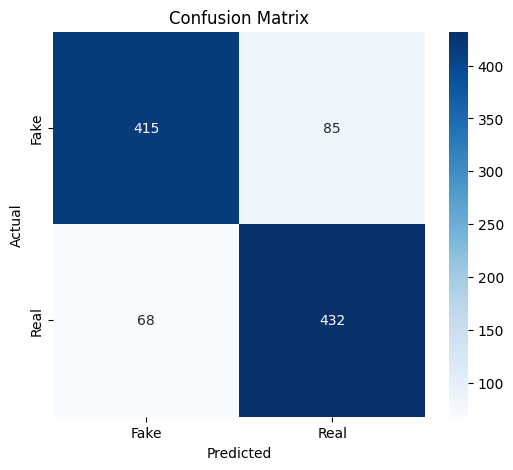

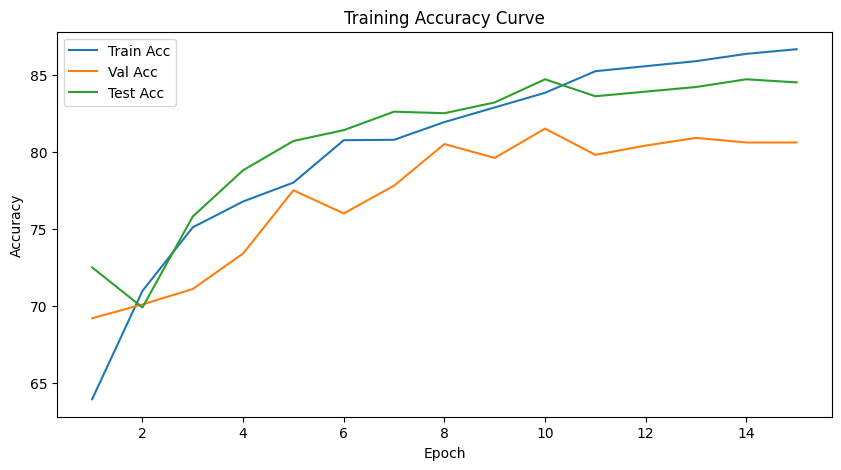

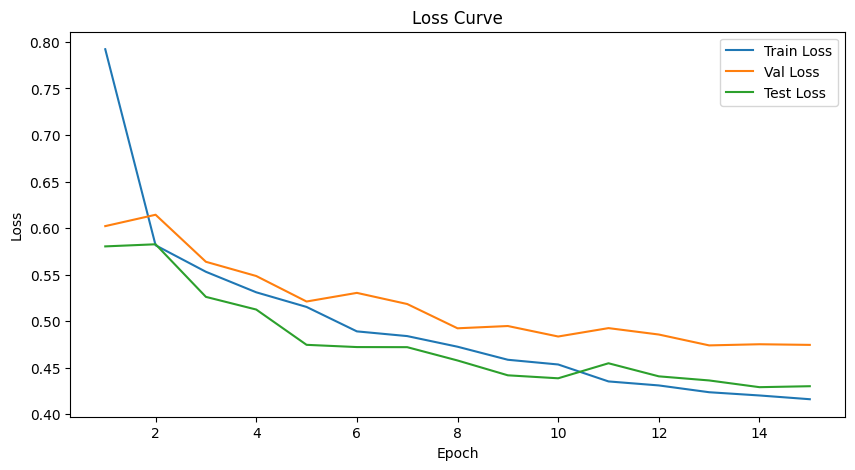


ALL OUTPUTS SAVED SUCCESSFULLY
Models Folder      : /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn/models
Checkpoints Folder : /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn/checkpoints
Logs Folder        : /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn/logs
Plots Folder       : /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn/plots
Inference Folder   : /content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn/inference


'\ncheckpoint = torch.load(\n    os.path.join(CHECKPOINT_DIR, "checkpoint_epoch_5.pth")\n)\n\nmodel.load_state_dict(checkpoint["model_state_dict"])\noptimizer.load_state_dict(checkpoint["optimizer_state_dict"])\nscheduler.load_state_dict(checkpoint["scheduler_state_dict"])\n\nstart_epoch = checkpoint["epoch"]\n'

In [ ]:

DATASET_PATH = "/content/drive/Subset_Dataset/"
# from google.colab import drive
# drive.mount('/content/drive')

TRAIN_DIR = os.path.join(DATASET_PATH, "final_train")
VAL_DIR   = os.path.join(DATASET_PATH, "val")
TEST_DIR  = os.path.join(DATASET_PATH, "test")

SAVE_DIR = "/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn"

MODEL_DIR      = os.path.join(SAVE_DIR, "models")
CHECKPOINT_DIR = os.path.join(SAVE_DIR, "checkpoints")
LOG_DIR        = os.path.join(SAVE_DIR, "logs")
PLOT_DIR       = os.path.join(SAVE_DIR, "plots")
INFER_DIR      = os.path.join(SAVE_DIR, "inference")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(INFER_DIR, exist_ok=True)

# ============================================================
# 17. SAVE TRAINING LOGS
# ============================================================
logs_df = pd.DataFrame(history)

logs_df.to_csv(
    os.path.join(LOG_DIR, "training_logs.csv"),
    index=False
)

# ============================================================
# 18. LOAD BEST MODEL
# ============================================================
# model.load_state_dict(
#     torch.load(os.path.join(MODEL_DIR, "best_model.pth"))
# )

# ============================================================
# 19. FINAL TEST EVALUATION
# ============================================================
test_loss, test_acc, labels, preds, probs, logits = evaluate(
    model,
    test_loader
)

# ============================================================
# 20. SAVE LOGITS
# ============================================================
np.save(
    os.path.join(INFER_DIR, "test_logits.npy"),
    logits
)

np.save(
    os.path.join(INFER_DIR, "test_probabilities.npy"),
    probs
)

# ============================================================
# 21. METRICS
# ============================================================
f1_macro = f1_score(labels, preds, average="macro")
f1_weighted = f1_score(labels, preds, average="weighted")

precision_weighted = precision_score(
    labels,
    preds,
    average="weighted"
)

recall_weighted = recall_score(
    labels,
    preds,
    average="weighted"
)

roc_auc = roc_auc_score(labels, probs[:, 1])

# ============================================================
# 22. PERFORMANCE REPORT
# ============================================================
print("\n==================================================")
print("TEST PERFORMANCE REPORT")
print("==================================================")

print(f"Accuracy          : {test_acc:.2f}%")
print(f"F1 (Macro)        : {f1_macro:.4f}")
print(f"F1 (Weighted)     : {f1_weighted:.4f}")
print(f"Precision (W)     : {precision_weighted:.4f}")
print(f"Recall (W)        : {recall_weighted:.4f}")
print(f"ROC-AUC (macro)   : {roc_auc:.4f}")
print(f"Test Loss         : {test_loss:.4f}")

print("==================================================")

# ============================================================
# 23. CLASSIFICATION REPORT
# ============================================================
report = classification_report(
    labels,
    preds,
    target_names=class_names
)

print("\nCLASSIFICATION REPORT\n")
print(report)

with open(os.path.join(LOG_DIR, "classification_report.txt"), "w") as f:
    f.write(report)

# ============================================================
# 24. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig(
    os.path.join(PLOT_DIR, "confusion_matrix.png")
)

plt.show()

# ============================================================
# 25. TRAINING CURVES
# ============================================================
epochs_range = range(1, EPOCHS + 1)

# Accuracy Curve
plt.figure(figsize=(10,5))

plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.plot(epochs_range, history["test_acc"], label="Test Acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curve")

plt.legend()

plt.savefig(
    os.path.join(PLOT_DIR, "accuracy_curve.png")
)

plt.show()

# ============================================================
# 26. LOSS CURVES
# ============================================================
plt.figure(figsize=(10,5))

plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.plot(epochs_range, history["test_loss"], label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()

plt.savefig(
    os.path.join(PLOT_DIR, "loss_curve.png")
)

plt.show()

# ============================================================
# 27. SAVE FINAL MODEL
# ============================================================
torch.save(
    model,
    os.path.join(MODEL_DIR, "final_complete_model.pth")
)

print("\n==================================================")
print("ALL OUTPUTS SAVED SUCCESSFULLY")
print("==================================================")

print(f"Models Folder      : {MODEL_DIR}")
print(f"Checkpoints Folder : {CHECKPOINT_DIR}")
print(f"Logs Folder        : {LOG_DIR}")
print(f"Plots Folder       : {PLOT_DIR}")
print(f"Inference Folder   : {INFER_DIR}")
print("==================================================")

# ============================================================
# 28. LOAD SAVED MODEL (EXAMPLE)
# ============================================================
"""
# LOAD MODEL

loaded_model = torch.load(
    os.path.join(MODEL_DIR, "final_complete_model.pth")
)

loaded_model.eval()

# LOAD WEIGHTS ONLY

model = SimpleCNN(NUM_CLASSES)

model.load_state_dict(
    torch.load(os.path.join(MODEL_DIR, "best_model.pth"))
)

model.to(device)
model.eval()
"""

# ============================================================
# 29. LOAD CHECKPOINT (EXAMPLE)
# ============================================================
"""
checkpoint = torch.load(
    os.path.join(CHECKPOINT_DIR, "checkpoint_epoch_5.pth")
)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

start_epoch = checkpoint["epoch"]
"""

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!rm -rf /content/drive

'0-S&M Methods for DS Formula Sheet.gdoc'
 1-s2.0-S0957417425024613-main.gdoc
 Classroom
'Colab Notebooks'
'Comparitive Analysis of ML & DL on DeepFake'
'Copy of Final Project Github Repo.gsheet'
'CV kh FR.pdf'
'Khansa - dataset.gsheet'
'KHANSA IT.pdf'
 my.jpg
'Truck Assignment Automation'
 ViT_Medical_FineTuning
'What is Riba (Interest) in Islam, and Why is it Strictly Prohibited? A Critical and Analytical Study in the Light of Qur’an, Sunnah, and Contemporary Economic Systems.gdoc'
'Z-Table & T-Table.gdoc'


In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn"

print("Exists:", os.path.exists(SAVE_DIR))

for root, dirs, files in os.walk(SAVE_DIR):
    print(f"\n{root}")
    for file in files:
        print(file)

Exists: True

/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn


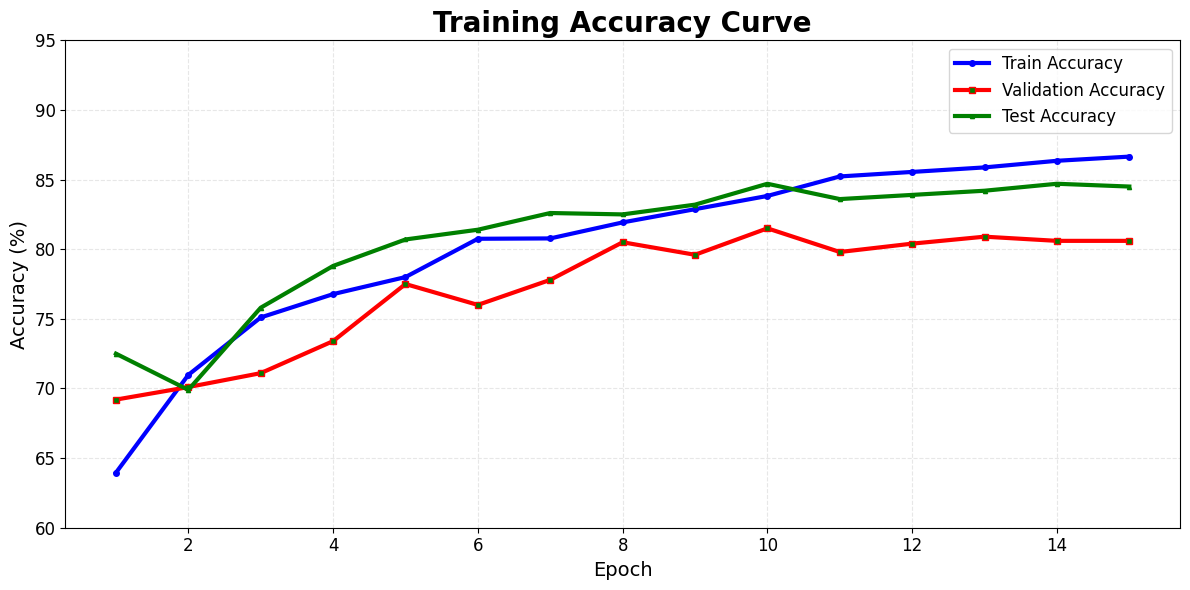

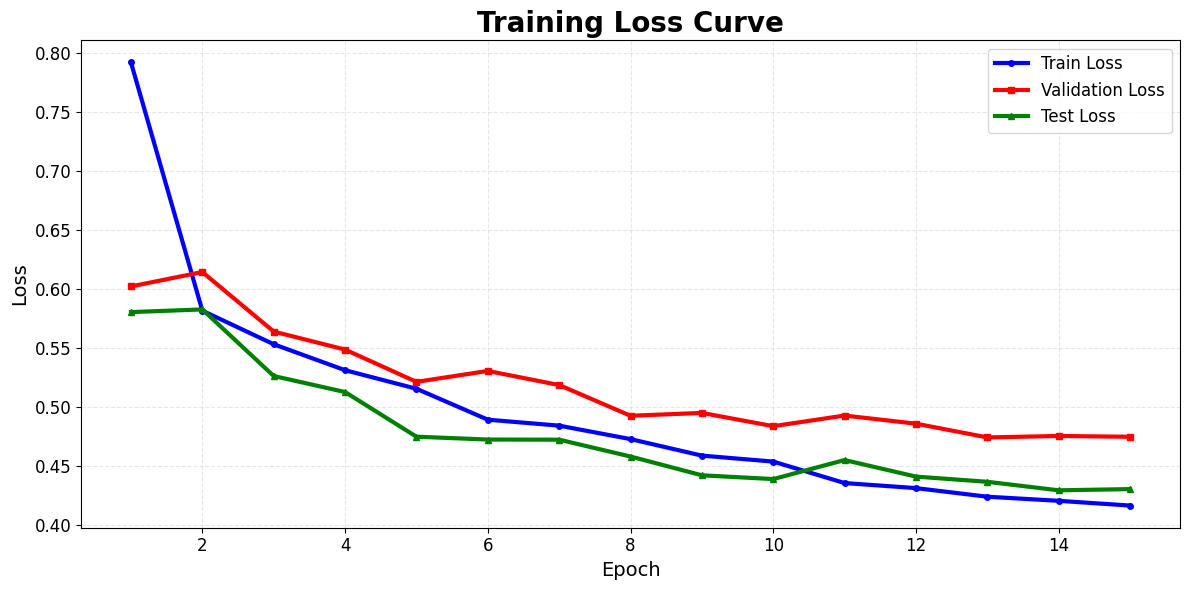

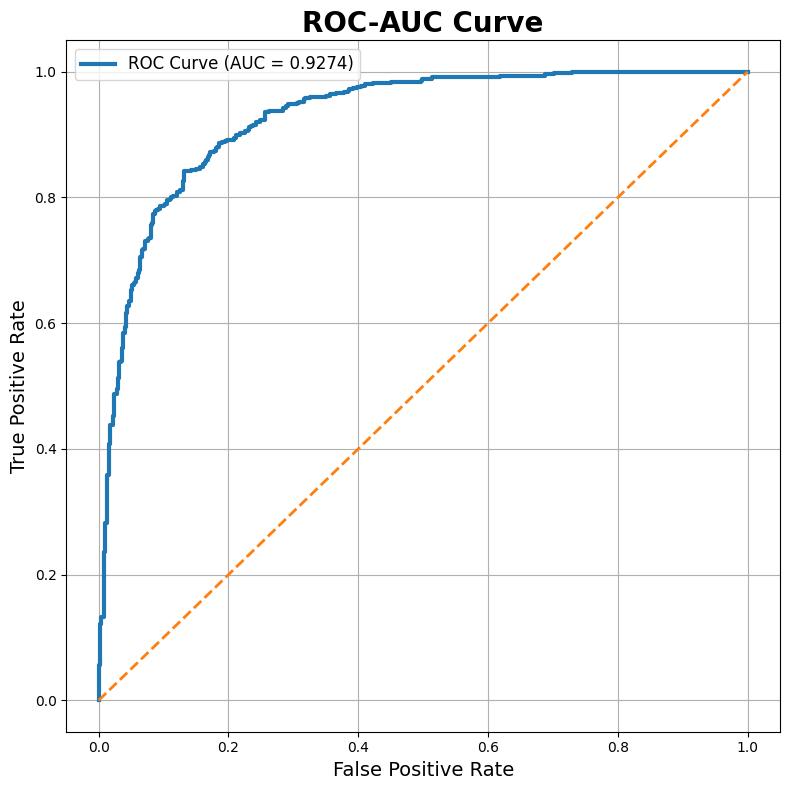

ROC-AUC Score: 0.9274

Generating t-SNE Visualization...


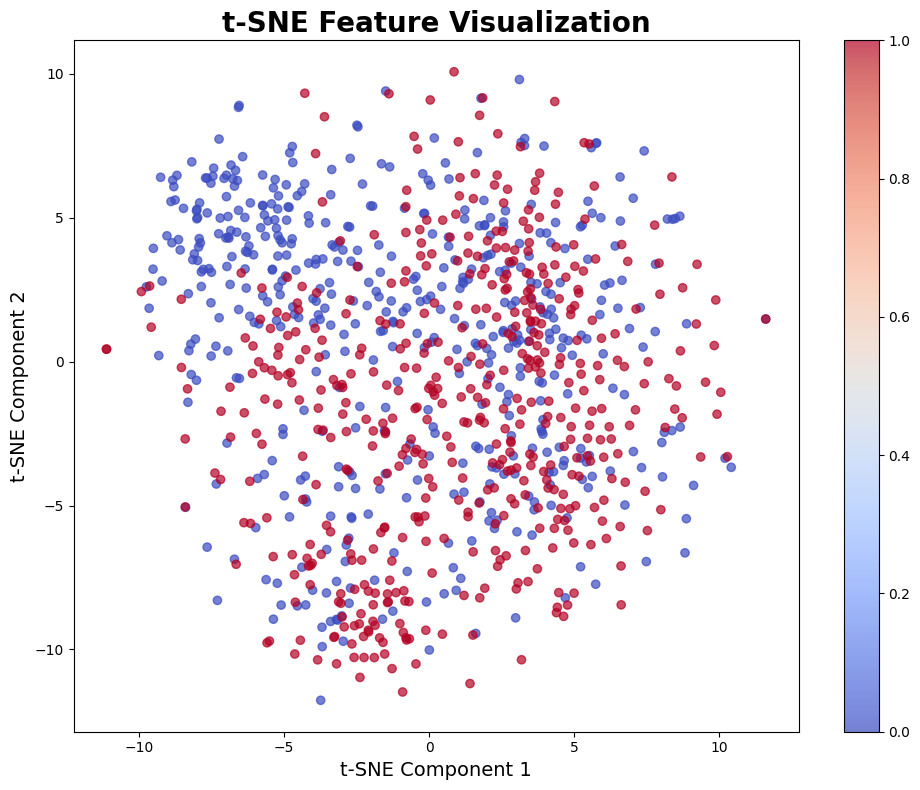


Generating Grad-CAM Visualizations...


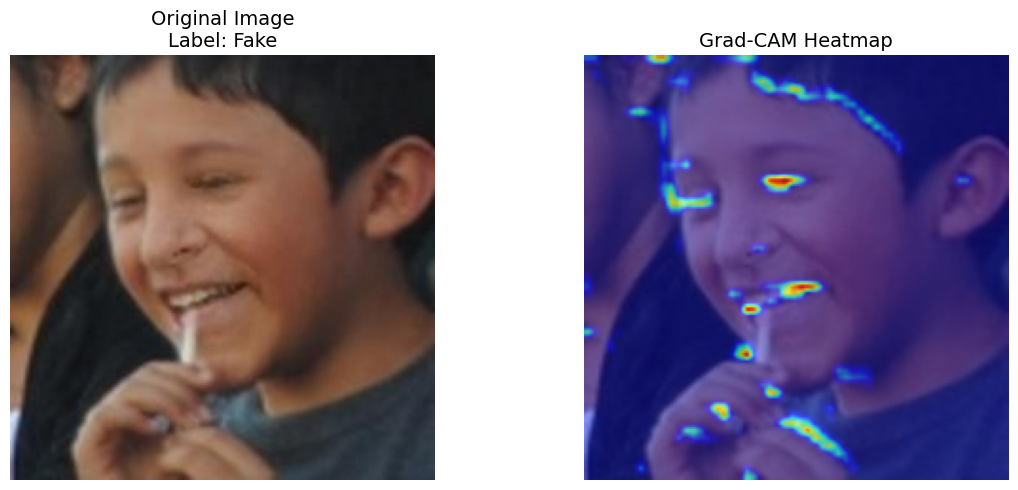


ALL BEAUTIFUL VISUALIZATIONS SAVED
Saved in:
/content/drive/MyDrive/Comparitive Analysis of ML & DL on DeepFake/deepfake_DL_results/simple_cnn/beautiful_visualizations

Generated Files:
- beautiful_accuracy_curve.png
- beautiful_loss_curve.png
- roc_auc_curve.png
- tsne_visualization.png
- gradcam_visualization.png


In [ ]:
# ============================================================
# BEAUTIFUL VISUALIZATION SUITE
# ============================================================
# Includes:
# 1. Beautiful Training Curves
# 2. ROC-AUC Curve
# 3. t-SNE Visualization
# 4. Grad-CAM Visualization
# ============================================================

# ============================================================
# INSTALLS
# ============================================================
!pip install -q scikit-learn opencv-python grad-cam

# ============================================================
# IMPORTS
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.metrics import roc_curve, auc

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ============================================================
# CREATE VISUALIZATION DIRECTORY
# ============================================================
VISUAL_DIR = os.path.join(SAVE_DIR, "beautiful_visualizations")
os.makedirs(VISUAL_DIR, exist_ok=True)


# STYLE SETTINGS
plt.style.use('default')

# ============================================================
# 1. BEAUTIFUL TRAINING CURVES
# ============================================================

epochs_range = range(1, EPOCHS + 1)

# ------------------------------------------------------------
# ACCURACY CURVE
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    epochs_range,
    history["train_acc"],
    marker='o',
    color='blue',
    markerfacecolor='blue',
    markersize=4,
    linewidth=3,
    label='Train Accuracy'
)

plt.plot(
    epochs_range,
    history["val_acc"],
    marker='s',
    color='red',
    markerfacecolor='green',
    markersize=4,
    linewidth=3,
    label='Validation Accuracy'
)

plt.plot(
    epochs_range,
    history["test_acc"],
    marker='^',
    color='green',
    markersize=3,
    linewidth=3,
    label='Test Accuracy'
)

plt.title(
    "Training Accuracy Curve",
    fontsize=20,
    fontweight='bold'
)

plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Accuracy (%)", fontsize=14)

plt.ylim(60, 95)
plt.yticks(np.arange(60, 96, 5))

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(VISUAL_DIR, "accuracy_curve.png"),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

# ------------------------------------------------------------
# LOSS CURVE
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot(
    epochs_range,
    history["train_loss"],
    marker='o',
    color='blue',
    markersize=4,
    linewidth=3,
    label='Train Loss'
)

plt.plot(
    epochs_range,
    history["val_loss"],
    marker='s',
    color='red',
    markersize=4,
    linewidth=3,
    label='Validation Loss'
)

plt.plot(
    epochs_range,
    history["test_loss"],
    marker='^',
    color='green',
    markersize=4,
    linewidth=3,
    label='Test Loss'
)

plt.title(
    "Training Loss Curve",
    fontsize=20,
    fontweight='bold'
)

plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Loss", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()

plt.savefig(
    os.path.join(VISUAL_DIR, "beautiful_loss_curve.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 2. ROC-AUC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(labels, probs[:, 1])

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,8))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=2
)

plt.title(
    "ROC-AUC Curve",
    fontsize=20,
    fontweight='bold'
)

plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)

plt.legend(fontsize=12)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(VISUAL_DIR, "roc_auc_curve.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

# ============================================================
# 3. t-SNE VISUALIZATION
# ============================================================

print("\nGenerating t-SNE Visualization...")

model.eval()

feature_vectors = []
feature_labels = []

with torch.no_grad():

    for images, lbls in test_loader:

        images = images.to(device)

        features = model.features(images)

        features = features.view(features.size(0), -1)

        feature_vectors.extend(features.cpu().numpy())
        feature_labels.extend(lbls.numpy())

feature_vectors = np.array(feature_vectors)
feature_labels = np.array(feature_labels)

# Reduce size for faster t-SNE
MAX_SAMPLES = 1000

if len(feature_vectors) > MAX_SAMPLES:

    indices = np.random.choice(
        len(feature_vectors),
        MAX_SAMPLES,
        replace=False
    )

    feature_vectors = feature_vectors[indices]
    feature_labels = feature_labels[indices]

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_results = tsne.fit_transform(feature_vectors)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    tsne_results[:,0],
    tsne_results[:,1],
    c=feature_labels,
    cmap='coolwarm',
    alpha=0.7
)

plt.title(
    "t-SNE Feature Visualization",
    fontsize=20,
    fontweight='bold'
)

plt.xlabel("t-SNE Component 1", fontsize=14)
plt.ylabel("t-SNE Component 2", fontsize=14)

plt.colorbar(scatter)

plt.tight_layout()

plt.savefig(
    os.path.join(VISUAL_DIR, "tsne_visualization.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# 4. GRAD-CAM VISUALIZATION
# ============================================================

print("\nGenerating Grad-CAM Visualizations...")

# ------------------------------------------------------------
# TARGET LAYER
# ------------------------------------------------------------
target_layer = model.features[-4]

cam = GradCAM(
    model=model,
    target_layers=[target_layer]
)

# ------------------------------------------------------------
# GET SAMPLE IMAGE
# ------------------------------------------------------------
sample_image, sample_label = test_dataset[0]

input_tensor = sample_image.unsqueeze(0).to(device)

# ------------------------------------------------------------
# GENERATE CAM
# ------------------------------------------------------------
grayscale_cam = cam(input_tensor=input_tensor)

grayscale_cam = grayscale_cam[0]

# ------------------------------------------------------------
# PREPARE IMAGE
# ------------------------------------------------------------
rgb_img = sample_image.permute(1,2,0).numpy()

# Unnormalize
rgb_img = rgb_img * IMAGENET_STD + IMAGENET_MEAN

rgb_img = np.clip(rgb_img, 0, 1)

# ------------------------------------------------------------
# OVERLAY CAM
# ------------------------------------------------------------
visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
plt.figure(figsize=(12,5))

# Original
plt.subplot(1,2,1)

plt.imshow(rgb_img)

plt.title(
    f"Original Image\nLabel: {class_names[sample_label]}",
    fontsize=14
)

plt.axis('off')

# GradCAM
plt.subplot(1,2,2)

plt.imshow(visualization)

plt.title(
    "Grad-CAM Heatmap",
    fontsize=14
)

plt.axis('off')

plt.tight_layout()

plt.savefig(
    os.path.join(VISUAL_DIR, "gradcam_visualization.png"),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# SAVE SUMMARY
# ============================================================

print("\n==================================================")
print("ALL BEAUTIFUL VISUALIZATIONS SAVED")
print("==================================================")

print(f"Saved in:\n{VISUAL_DIR}")

print("\nGenerated Files:")
print("- beautiful_accuracy_curve.png")
print("- beautiful_loss_curve.png")
print("- roc_auc_curve.png")
print("- tsne_visualization.png")
print("- gradcam_visualization.png")

print("==================================================")

## 1. **SIMPLE CNN MODEL**

The Simple CNN (Convolutional Neural Network) model is implemented as a baseline deep learning architecture for deepfake image classification. CNNs automatically learn spatial features from images using convolution operations.

The architecture consists of multiple convolutional layers followed by ReLU activation and max-pooling layers for feature extraction and dimensionality reduction. Fully connected layers are then used for binary classification (Fake vs Real).

**Parameters Used:**
* Input Image Size: 224 × 224
* Number of Classes: 2 (Fake, Real)
* Convolution Filters: 32, 64, 128
* Kernel Size: 3 × 3
* Pooling Layer: MaxPooling (2 × 2)
* Activation Function: ReLU
* Dropout Rate: 0.5
* Hyperparameters Used
* Batch Size: 8
* Optimizer: Adam
* Learning Rate: 0.001
* Loss Function: CrossEntropyLoss
* Epochs: 10
* Shuffle: True (for training data)


**The Simple CNN model helps evaluate the effectiveness of a lightweight architecture for detecting forged facial patterns in deepfake images.**

